In [93]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
%matplotlib inline
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

# Statistics

In [7]:
def get_statistics(data):
    data_dir = os.path.join('dataset',data)
    rating = pd.read_csv(os.path.join(data_dir, 'rating.csv'))
    trust = pd.read_csv(os.path.join(data_dir, 'trustnetwork.csv'))
    # total users
    total_user = set(rating.user_id.unique()).union(set(trust.user_id_1.unique())).union(set(trust.user_id_2.unique()))
    print(f"Total Users : {len(total_user)}")
    # total items
    print(f"Total Items : {rating.product_id.nunique()}")
    # total interactions
    print(f"Total Interactions : {rating.shape[0]}")
    # total social interactions
    print(f"Total Trust Links : {trust.shape[0]}")
    # Rating graph sparsity
    print(f"Rating Density : {rating.shape[0]/(rating.user_id.nunique()*rating.product_id.nunique())*100:.4f}%")
    # Social graph sparsity
    print(f"Trust Density : {(trust.shape[0]/len(total_user)**2)*100:.4f}%")

In [5]:
get_statistics('ciao_timestamp')

Total Users : 7317
Total Items : 104957
Total Interactions : 281867
Total Trust Links : 111781
Rating Sparsity : 0.0367%
Trust Sparsity : 0.2088%


In [8]:
get_statistics('epinions')

Total Users : 18088
Total Items : 261649
Total Interactions : 756345
Total Trust Links : 355121
Rating Density : 0.0160%
Trust Density : 0.1085%


In [9]:
get_statistics('yelp')

Total Users : 315777
Total Items : 143414
Total Interactions : 2548440
Total Trust Links : 226262
Rating Density : 0.0056%
Trust Density : 0.0002%


In [10]:
get_statistics('Douban')

Total Users : 37112
Total Items : 68955
Total Interactions : 5900563
Total Trust Links : 111568
Rating Density : 0.2306%
Trust Density : 0.0081%


In [117]:
batch_global_rating = torch.load('batch_global_rating.pt')
batch_user_seq = torch.load('batch_user_seq.pt')
batch_item_seq = torch.load('batch_item_seq.pt')

In [118]:
global_attn_0 = torch.load('global_attn_0.pt')
global_attn_50 = torch.load('global_attn_50.pt')
global_attn_100 = torch.load('global_attn_100.pt')
global_attn_150 = torch.load('global_attn_150.pt')
global_attn_200 = torch.load('global_attn_200.pt')

# Attention Heatmap(Preference Attention)

- Assumption
    - Preference Attention map은 user-item의 rating과 양의 상관관계가 존재할 것이다. 단, 완전히 값이 일치하는 방향으로는 가지 않을 것이다.
- Proof
    - Preference Attention map에 대한 값과 Rating Matrix에 대한 값의 Trend -> HeatMap으로 표현
- Split
    - Train/Test 중에서 어떤걸 사용해서 할지?
    - 일단 둘다 해보고, 사용하기 좋은쪽 고르기
        - Train : [학습 시작하기 전 - 학습 중간 - 학습 후] 각각 뽑아서 비교
        - Test : 그냥 비교

In [71]:
def get_corr(attn, rating=batch_global_rating):
    mask = (rating!=0)
    attn = attn*mask
    rating = rating*mask
    # batch를 축으로 pearson coefficient계산

    mean_attn = attn.mean(dim=0, keepdim=True)
    mean_rating = rating.mean(dim=0, keepdim=True)

    # 분자 : covariance
    cov = ((attn-mean_attn)*(rating-mean_rating)).sum(dim=0)
    # 분모 : 표준편차의 곱
    den = torch.sqrt(((attn-mean_attn)**2).sum(dim=0) * ((rating-mean_rating)**2).sum(dim=0))+1e-10

    corr = cov/den
    
    return corr

tensor(0.0213)


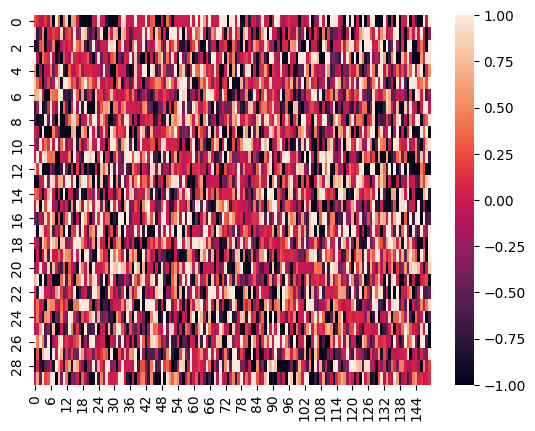

In [72]:
global_attn_before = torch.load('global_attn_before.pt')
corr_0 = get_corr(global_attn_before)
sns.heatmap(corr_0)
print(corr_0.mean())

tensor(-0.3788)


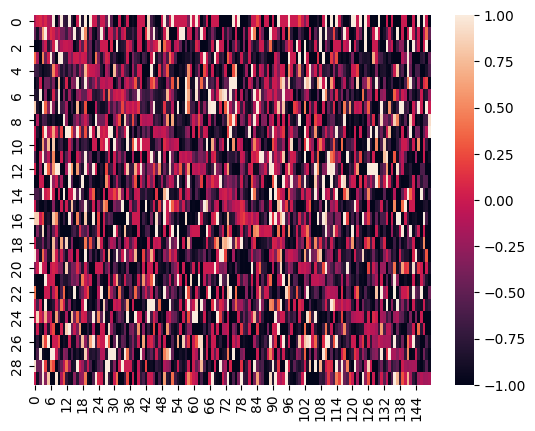

In [73]:
global_attn_50 = torch.load('global_attn_mid_50.pt')
corr_50 = get_corr(global_attn_50)
sns.heatmap(corr_50)
print(corr_50.mean())

tensor(-0.1246)


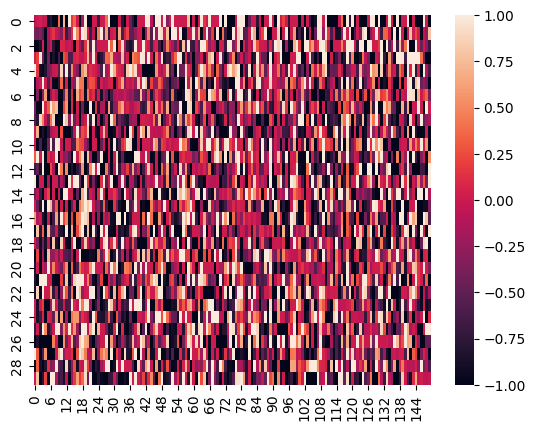

In [74]:
global_attn_100 = torch.load('global_attn_mid_100.pt')
corr_100 = get_corr(global_attn_100)
sns.heatmap(corr_100)
print(corr_100.mean())

tensor(-0.1109)


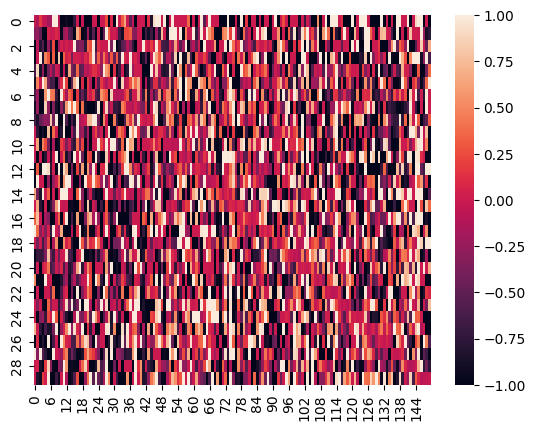

In [75]:
global_attn_150 = torch.load('global_attn_mid_150.pt')
corr_150 = get_corr(global_attn_150)
sns.heatmap(corr_150)
print(corr_150.mean())

tensor(-0.0355)


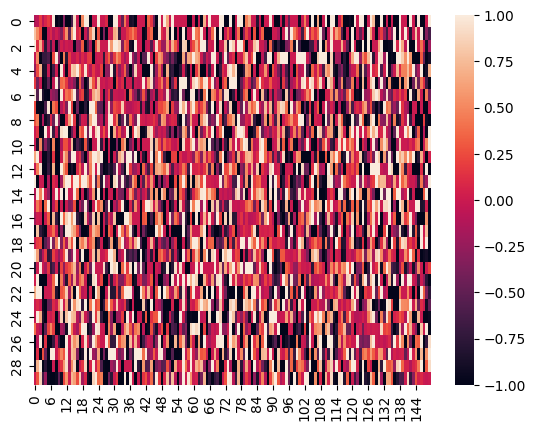

In [76]:
global_attn_200 = torch.load('global_attn_mid_200.pt')
corr_200 = get_corr(global_attn_200)
sns.heatmap(corr_200)
print(corr_200.mean())

# 일반적인 값으로 Trend 시각화

In [119]:
# rating -> softmax값으로 변환
scaled_rating = F.softmax(batch_global_rating, dim=-1)

<Axes: >

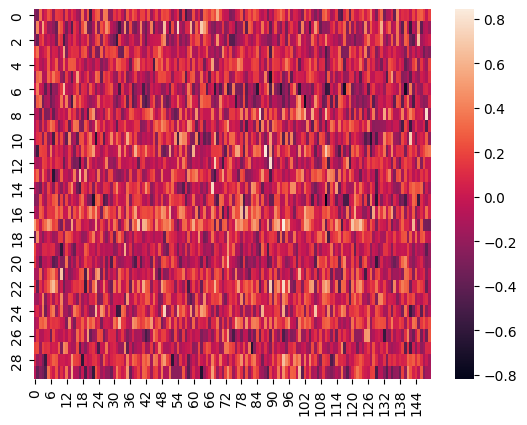

In [120]:
sns.heatmap(global_attn_before[0])

<Axes: >

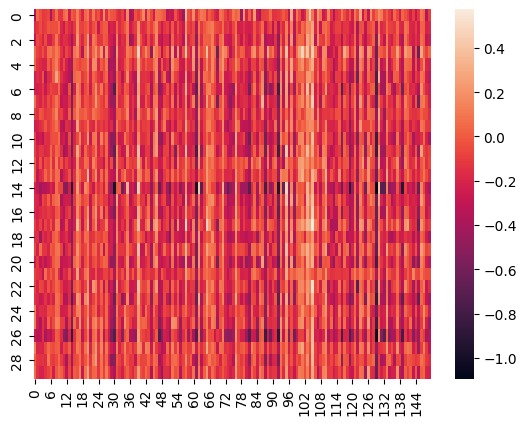

In [121]:
sns.heatmap(global_attn_50[0])

<Axes: >

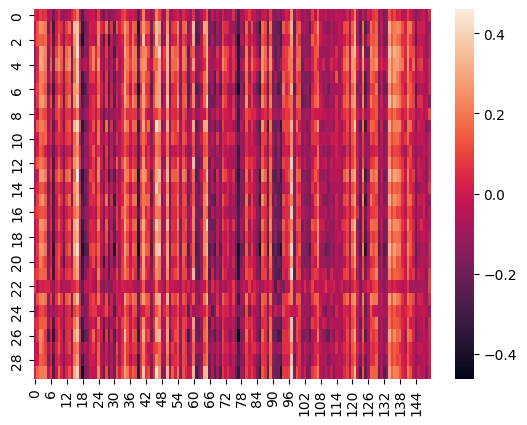

In [122]:
sns.heatmap(global_attn_100[0])

<Axes: >

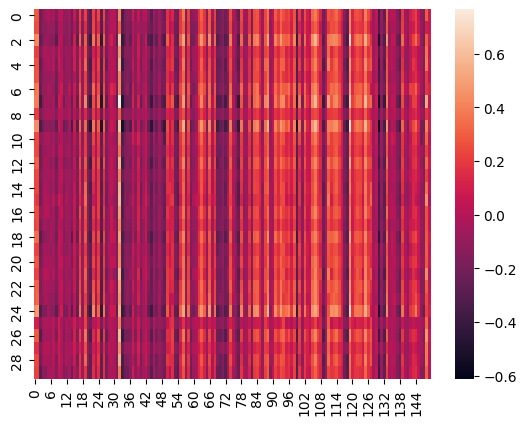

In [123]:
sns.heatmap(global_attn_150[0])

<Axes: >

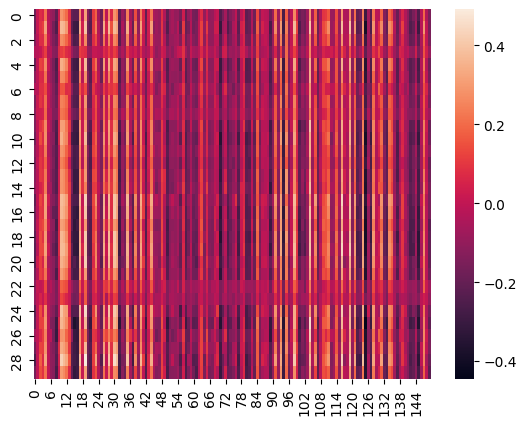

In [124]:
sns.heatmap(global_attn_200[0])

- attention map에 대한 heatmap을 보니, 학습이 진행될수록 user별로 비슷한 pattern이 뚜렷해지는 것을 확인할 수 있음
- 따라서, 상관계수 분석/분포에 대한 분석을 통해 attention 값이 비슷한 user를 select
    - 그리고 그 user가 interaction한 item + rating을 분석해 비슷한 representation을 갖추고 있는지 확인

In [125]:
cos_sim = cosine_similarity(global_attn_200[0])

In [152]:
highest_idx = np.argsort(cos_sim, axis=1)[:15,-2]

In [153]:
pairs = list(zip(np.arange(15), highest_idx))

In [154]:
user_lst = []
attention_lst = []
for a,b in pairs:
    user_lst.append(batch_user_seq[0][a])
    user_lst.append(batch_user_seq[0][b])
    attention_lst.append(global_attn_200[0][a])
    attention_lst.append(global_attn_200[0][b])

In [156]:
attention_before = []
for a,b in pairs:
    attention_before.append(global_attn_0[0][a])
    attention_before.append(global_attn_0[0][b])

## Encoder-Decoder w/o encoder training

In [ ]:
global_attn_200_abl = torch.load('global_attn')

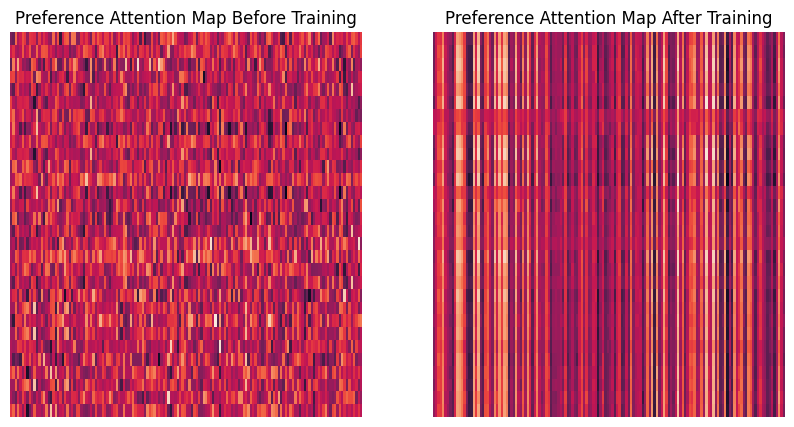

In [188]:
fig,ax = plt.subplots(1,2, figsize=(10,5))
sns.heatmap(attention_before, ax=ax[0], cbar=False)
sns.heatmap(attention_lst, ax=ax[1], cbar=False)
# tick제거
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
# labels
ax[0].set_title('Preference Attention Map Before Training')
ax[1].set_title('Preference Attention Map After Training')

plt.savefig('attention_heatmap.pdf')

<Axes: >

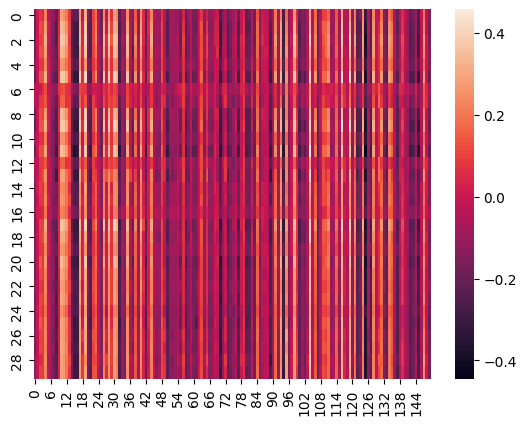

In [155]:
sns.heatmap(attention_lst)

<Axes: >

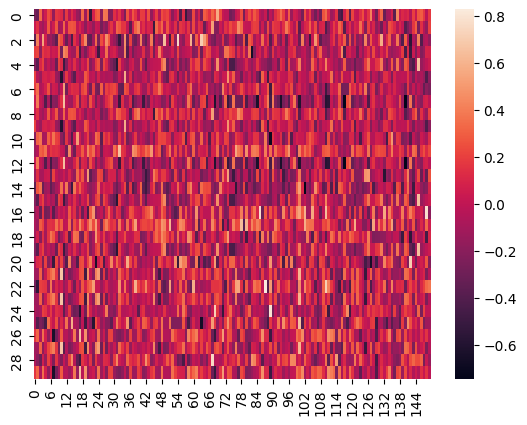

In [157]:
sns.heatmap(attention_before)

In [162]:
print(user_lst[:2])

[tensor(688), tensor(581)]


In [ ]:
# 실제 interaction한 item과 rating이 pair간에 비슷한지 비교
rating_df = pd.read_csv(os.path.join('dataset','ciao_timestamp','rating.csv'))

,user_id,product_id,rating,product_degree,user_degree
222828,688,76142,5,1,1
222894,688,949,4,50,1
222895,688,76156,4,1,1
222896,688,68171,3,16,1
222897,688,72365,4,29,1
222964,688,18876,4,2,1
222965,688,4060,4,34,1
223025,688,5900,5,38,1
223297,688,76327,4,2,1
253704,688,90071,4,1,1


In [166]:
a = rating_df[rating_df.user_id==688]
b = rating_df[rating_df.user_id==581]